In [12]:
import numpy as np

class MyLinearRegression:
    def __init__(self):
        self.coef_ = None      # 权重
        self.intercept_ = None # 偏置项

    def fit(self, X, y):
        """
        拟合线性回归模型
        X: ndarray, shape (n_samples, n_features)
        y: ndarray, shape (n_samples,) 或 (n_samples, 1)
        """
        # 确保 X 是二维
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        # 确保 y 是二维列向量
        y = np.array(y)
        if y.ndim == 1:
            y = y.reshape(-1, 1)

        # 在 X 前加一列 1，用于计算截距
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])

        # 正规方程求解 theta = (X^T X)^(-1) X^T y
        theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

        # 拆分截距和系数
        self.intercept_ = theta[0]
        self.coef_ = theta[1:].flatten()

    def predict(self, X):
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        return X @ self.coef_.reshape(-1, 1) + self.intercept_


In [13]:
# 生成一些数据
np.random.seed(0)
X = 2 * np.random.rand(10, 2)
y = 4 + 3*X[:,0].reshape(-1,1) + 5*X[:,1].reshape(-1,1) + np.random.randn(10,1)

# 拟合模型
lr = MyLinearRegression()
lr.fit(X, y)

print("截距:", lr.intercept_)
print("系数:", lr.coef_)

# 预测
X_new = np.array([[0,0], [1,1]])
y_pred = lr.predict(X_new)
print("预测结果:\n", y_pred)


截距: [3.92450096]
系数: [1.68459727 6.1078051 ]
预测结果:
 [[ 3.92450096]
 [11.71690334]]


拟合结果:
截距: [4.54667647]
系数: [3.15915082 4.67706499]

真实值 vs 预测值:
          真实值        预测值
0   13.279625  14.704220
1   13.966239  13.452025
2   13.466532  13.265233
3   14.007010  15.653245
4   15.104644  14.222150
5   15.935189  14.496386
6   17.843013  16.793905
7    5.117585   5.810523
8   11.376756  12.462857
9   18.423514  17.601512
10  17.460119  18.205315
11  15.796613  14.763614
12  11.317132  11.279874
13  15.283448  14.288982
14  11.634076  11.722673
15  14.036244  13.460501
16  12.431742  12.745977
17  12.074964  10.442839
18  13.968826  14.184963
19  16.882681  16.887397
20  12.410518  10.906210
21   7.440283   9.517878
22  13.436494  15.032743
23   7.520955   7.081930
24   8.356554   9.941846
25  13.750817  12.252087
26  10.537072  11.746061
27   6.118901   7.375333
28  12.374508  11.042534
29  10.722635   9.779357
30   7.925128   6.583558
31  10.225852   9.986146
32   8.005520   9.237846
33  11.807037  10.642257
34   9.720650  10.739982
35  15.347725  15.100066
36  16.8562

<Figure size 600x400 with 0 Axes>

Text(0.5, 0, '样本索引')

Text(0, 0.5, 'y 值')

Text(0.5, 1.0, '真实值 vs 预测值对比')

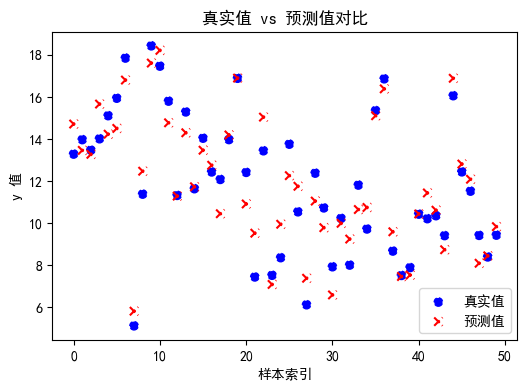

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 1️⃣ 生成可调数据
# -----------------------------
np.random.seed(0)

n_samples = 50        # 样本数，可修改
n_features = 2        # 特征数，可修改

# 随机生成 X
X = 2 * np.random.rand(n_samples, n_features)

# 生成 y: 自定义截距和系数
intercept_true = 4
coef_true = np.array([3, 5])  # 与 n_features 对应
noise_scale = 1.0             # 噪声大小，可修改

y = intercept_true + X @ coef_true.reshape(-1, 1) + np.random.randn(n_samples, 1)

# -----------------------------
# 2️⃣ 拟合模型
# -----------------------------
lr = MyLinearRegression()
lr.fit(X, y)

print("拟合结果:")
print("截距:", lr.intercept_)
print("系数:", lr.coef_)

# -----------------------------
# 3️⃣ 预测
# -----------------------------
y_pred = lr.predict(X)  # 对训练集做预测

# -----------------------------
# 4️⃣ 结果显示
# -----------------------------
# 表格对比
df = pd.DataFrame({
    "真实值": y.flatten(),
    "预测值": y_pred.flatten()
})
print("\n真实值 vs 预测值:")
print(df)

# 可视化对比
plt.figure(figsize=(6,4))
plt.scatter(range(n_samples), y, color='blue', label='真实值')
plt.scatter(range(n_samples), y_pred, color='red', marker='x', label='预测值')
plt.xlabel("样本索引")
plt.ylabel("y 值")
plt.title("真实值 vs 预测值对比")
plt.legend()
plt.show()


拟合结果:
截距: [4.54667647]
系数: [3.15915082 4.67706499]

真实值 vs 预测值:
          真实值        预测值
0   13.279625  14.704220
1   13.966239  13.452025
2   13.466532  13.265233
3   14.007010  15.653245
4   15.104644  14.222150
5   15.935189  14.496386
6   17.843013  16.793905
7    5.117585   5.810523
8   11.376756  12.462857
9   18.423514  17.601512
10  17.460119  18.205315
11  15.796613  14.763614
12  11.317132  11.279874
13  15.283448  14.288982
14  11.634076  11.722673
15  14.036244  13.460501
16  12.431742  12.745977
17  12.074964  10.442839
18  13.968826  14.184963
19  16.882681  16.887397
20  12.410518  10.906210
21   7.440283   9.517878
22  13.436494  15.032743
23   7.520955   7.081930
24   8.356554   9.941846
25  13.750817  12.252087
26  10.537072  11.746061
27   6.118901   7.375333
28  12.374508  11.042534
29  10.722635   9.779357
30   7.925128   6.583558
31  10.225852   9.986146
32   8.005520   9.237846
33  11.807037  10.642257
34   9.720650  10.739982
35  15.347725  15.100066
36  16.8562

<Figure size 600x400 with 0 Axes>

Text(0.5, 0, '样本索引')

Text(0, 0.5, 'y 值')

Text(0.5, 1.0, '真实值 vs 预测值对比')

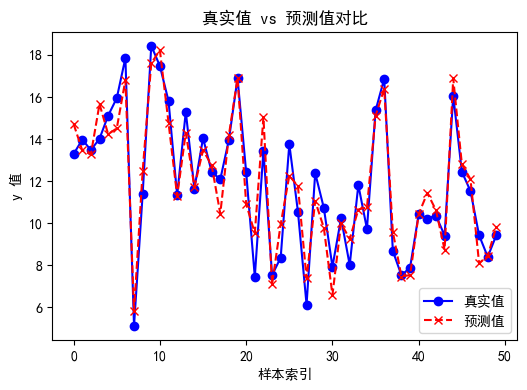

Text(0.5, 0, '特征1')

Text(0.5, 0.5, '特征2')

Text(0.5, 0, 'y 值')

Text(0.5, 0.92, '二维特征拟合平面')

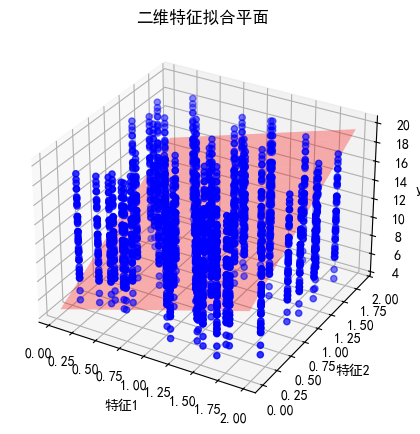

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# 1️⃣ 可调数据生成
# -----------------------------
np.random.seed(0)

n_samples = 50       # 样本数
n_features = 2       # 特征数，可修改为 1,2,3
intercept_true = 4
coef_true = np.array([3, 5, 2][:n_features])  # 截取对应数量
noise_scale = 1.0

# 生成 X
X = 2 * np.random.rand(n_samples, n_features)

# 生成 y
y = intercept_true + X @ coef_true.reshape(-1, 1) + noise_scale * np.random.randn(n_samples, 1)

# -----------------------------
# 2️⃣ 拟合模型
# -----------------------------
lr = MyLinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)

print("拟合结果:")
print("截距:", lr.intercept_)
print("系数:", lr.coef_)

# -----------------------------
# 3️⃣ 表格对比
# -----------------------------
df = pd.DataFrame({
    "真实值": y.flatten(),
    "预测值": y_pred.flatten()
})
print("\n真实值 vs 预测值:")
print(df)

# -----------------------------
# 4️⃣ 可视化
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(range(n_samples), y, 'o-', color='blue', label='真实值')   # 连线 + 点
plt.plot(range(n_samples), y_pred, 'x--', color='red', label='预测值')  # 预测值连线
plt.xlabel("样本索引")
plt.ylabel("y 值")
plt.title("真实值 vs 预测值对比")
plt.legend()
plt.show()

# -----------------------------
# 5️⃣ 多维特征可视化
# -----------------------------
if n_features == 1:
    # 1D 特征，简单画线
    plt.scatter(X[:,0], y, color='blue', label='真实值')
    plt.plot(X[:,0], y_pred, color='red', label='拟合线')
    plt.xlabel("特征1")
    plt.ylabel("y 值")
    plt.title("一维特征拟合")
    plt.legend()
    plt.show()

elif n_features == 2:
    # 2D 特征，画拟合平面
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:,0], X[:,1], y, color='blue', label='真实值')
    
    # 生成网格绘制拟合平面
    x1_grid, x2_grid = np.meshgrid(np.linspace(X[:,0].min(), X[:,0].max(), 20),
                                   np.linspace(X[:,1].min(), X[:,1].max(), 20))
    y_grid = lr.intercept_ + lr.coef_[0]*x1_grid + lr.coef_[1]*x2_grid
    ax.plot_surface(x1_grid, x2_grid, y_grid, color='red', alpha=0.3)

    ax.set_xlabel("特征1")
    ax.set_ylabel("特征2")
    ax.set_zlabel("y 值")
    ax.set_title("二维特征拟合平面")
    plt.show()

elif n_features == 3:
    # 3D 特征 → 绘制散点，拟合超平面不可直接可视化完整，但可以画切片
    print("三维特征可视化暂时只显示散点，拟合平面可通过切片或投影观察")
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[:,0], X[:,1], X[:,2], c=y.flatten(), cmap='viridis')
    ax.set_xlabel("特征1")
    ax.set_ylabel("特征2")
    ax.set_zlabel("特征3")
    plt.title("三维特征散点")
    plt.show()


In [9]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
#teacher draft
class MyLinearRegression:
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        one = np.ones(shape=(X.shape[0], 1))
        X = np.concatenate([one, X], axis=1)
        w = np.linalg.inv(X.T @ X) @ X.T @ y
        self.coef_ = w[1:]
        self.intercept_ = w[0]
        # 根据惯例，fit方法返回自身，便于链式调用。
        return self
    
    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_
    

X, y, w = make_regression(n_samples=1000, n_features=5, noise=1.5, coef=True, random_state=0)

X
y
w
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
lr = MyLinearRegression()
lr.fit(X_train, y_train)
print(w)
print(lr.coef_)
print(lr.intercept_)
y_pred = lr.predict(X_test)
print(r2_score(y_test, y_pred))

array([[-1.71864988,  0.96962373,  0.19677009,  0.14346393, -1.05695677],
       [-0.99819173, -1.00432271, -0.76670485, -1.06774201, -1.37304255],
       [-1.65280364,  0.17468009, -1.40025621,  0.06389619,  1.06592682],
       ...,
       [ 0.76500198,  0.03038613,  0.70713474, -2.25625012,  0.86766522],
       [-0.70434114,  0.37494836, -0.99927847, -0.62729906,  1.07470386],
       [-0.69204985,  1.02017271, -0.11054066,  0.28634369,  1.53637705]])

array([-2.23989175e+01, -2.15024804e+02, -4.00056793e+01,  6.24742187e+01,
       -7.34729780e+01,  1.44743449e+01, -1.26758001e+01, -3.15773571e+01,
        1.63617288e+01, -9.82036965e+01, -1.16902525e+02,  5.18669583e+01,
        8.20545435e+01, -4.34144882e+01,  5.47408114e+01,  3.59341182e+00,
       -8.39939034e+01, -2.30128467e+02,  1.72971898e+01,  1.29401049e+02,
       -8.14475369e+01,  4.32900388e+01,  3.64917466e+01, -4.69514427e+01,
        6.53235110e+01,  8.35156278e+01, -7.01368223e+01, -7.63079181e+01,
       -4.93364422e+01,  1.72827813e+01, -3.87996772e+01, -4.38992817e+01,
        8.76012808e+01, -3.25971160e+01, -1.23289493e+02,  3.90401025e+01,
       -1.94263196e+02, -2.64288097e+01, -7.67812124e+01, -6.59333157e+01,
       -1.00419773e+02, -1.01518913e+02,  1.13019816e+02, -9.93450288e+01,
       -3.33923738e+01,  5.11160085e+01, -2.22153099e+01,  4.09192183e+01,
       -1.89593903e+01,  9.73702406e+01,  9.16697939e+00,  9.75475484e-01,
        6.14225622e+01,  

array([41.20593377, 66.49948238, 10.71453179, 60.19514224, 25.96147771])

[41.20593377 66.49948238 10.71453179 60.19514224 25.96147771]
[41.15859039 66.48588073 10.75705702 60.28356395 25.87836854]
0.024662515742683355
0.9997747511958435
